In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

# Метрики регрессии
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    max_error,
    explained_variance_score
)

# Метрики классификации
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

# Метрики кластеризации
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Модели и данные
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print("Библиотеки загружены!")

Библиотеки загружены!


In [ ]:
# 3 датасета для реальных задач:
#   1. Регрессия — прогноз времени доставки заказа
#   2. Классификация — отток клиентов интернет‑магазина
#   3. Кластеризация — сегментация покупателей


np.random.seed(42)

# Регрессия: время доставки заказа (минуты)
N_reg = 500
# Признаки: расстояние до клиента (км), количество товаров в заказе, час дня (0-23)
distance = np.random.uniform(0.5, 30, N_reg)           # расстояние от 0.5 до 30 км
items_count = np.random.randint(1, 15, N_reg)          # количество товаров в заказе
hour_of_day = np.random.randint(8, 22, N_reg)          # час оформления заказа (8-21)
# Время доставки зависит от признаков + шум
delivery_time = (20 + distance * 2.5 + items_count * 3 + (hour_of_day > 18) * 15 + np.random.normal(0, 10, N_reg))
X_reg = np.column_stack([distance, items_count, hour_of_day])  # форма (500, 3)
y_reg = delivery_time

# Обучаем модель линейной регрессии
reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)
y_reg_pred = reg_model.predict(X_reg)

# лассификация: отток клиентов интернет‑магазина-
N_clf = 1000
# Признаки: частота визитов в месяц, средний чек, возвращённых товаров, дней с последнего визита
visits_per_month = np.random.normal(5, 3, N_clf).clip(0)     # визитов в месяц
avg_order_value = np.random.normal(3000, 1500, N_clf).clip(0) # средний чек, руб.
returns_ratio = np.random.beta(2, 10, N_clf)                  # доля возвратов (0-1)
days_since_last = np.random.exponential(30, N_clf)             # дней с последнего визита
# Отток (churn): логика — клиент уходит, если редко заходит ИЛИ много возвращает ИЛИ давно не был
churn_prob = 1 / (1 + np.exp(-( -1.5 + returns_ratio*3 - visits_per_month*0.2 + days_since_last*0.05 )))
churn = (np.random.random(N_clf) < churn_prob).astype(int)

X_clf = np.column_stack([visits_per_month, avg_order_value, returns_ratio, days_since_last])
y_clf = churn

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)
clf_model = LogisticRegression(max_iter=500)
clf_model.fit(X_tr, y_tr)
y_clf_pred = clf_model.predict(X_te)
y_clf_proba = clf_model.predict_proba(X_te)[:, 1]  # вероятность класса 1 (отток)

# Кластеризация: сегментация покупателей
N_clus = 300
# Признаки: среднемесячные траты (руб.), количество категорий товаров, частота покупок в месяц
A_spend = np.random.normal(5000, 1500, 100)
A_categ = np.random.randint(1, 4, 100)
A_freq = np.random.normal(2, 0.8, 100)

B_spend = np.random.normal(15000, 3500, 100)
B_categ = np.random.randint(3, 8, 100)
B_freq = np.random.normal(6, 1.5, 100)

C_spend = np.random.normal(35000, 8000, 100)
C_categ = np.random.randint(5, 12, 100)
C_freq = np.random.normal(14, 3, 100)

X_clus = np.column_stack([np.concatenate([A_spend, B_spend, C_spend]),
                          np.concatenate([A_categ, B_categ, C_categ]),
                          np.concatenate([A_freq, B_freq, C_freq])])
y_clus_true = np.array([0]*100 + [1]*100 + [2]*100)  # истинные метки (только для оценки)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_clus_pred = kmeans.fit_predict(X_clus)

print("Данные готовы!")

Данные готовы!


## МЕТРИКИ РЕГРЕССИИ — прогноз времени доставки

In [ ]:
# MAE — среднее абсолютное отклонение в минутах
mae = mean_absolute_error(y_reg, y_reg_pred)
print(f"MAE: {mae:.1f} мин — в среднем модель ошибается на столько минут")

# MSE — среднеквадратичная ошибка (сильно штрафует большие опоздания)
mse = mean_squared_error(y_reg, y_reg_pred)
print(f"MSE: {mse:.1f} мин² — штрафует крупные промахи")

# RMSE — корень из MSE, возвращает к минутам
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.1f} мин — как MAE, но чувствительнее к выбросам")

# R² — доля объяснённой дисперсии (1.0 — идеально)
r2 = r2_score(y_reg, y_reg_pred)
print(f"R²: {r2:.3f} — модель объясняет {r2:.1%} вариации времени доставки")

# Max Error — худший случай (самая большая ошибка)
max_err = max_error(y_reg, y_reg_pred)
print(f"Max Error: {max_err:.1f} мин — самый большой промах модели")

# Explained Variance — аналогично R², но без штрафа за смещение
evs = explained_variance_score(y_reg, y_reg_pred)
print(f"Explained Variance: {evs:.3f}")

MAE: 9.0 мин — в среднем модель ошибается на столько минут
MSE: 124.8 мин² — штрафует крупные промахи
RMSE: 11.2 мин — как MAE, но чувствительнее к выбросам
R²: 0.827 — модель объясняет 82.7% вариации времени доставки
Max Error: 32.6 мин — самый большой промах модели
Explained Variance: 0.827


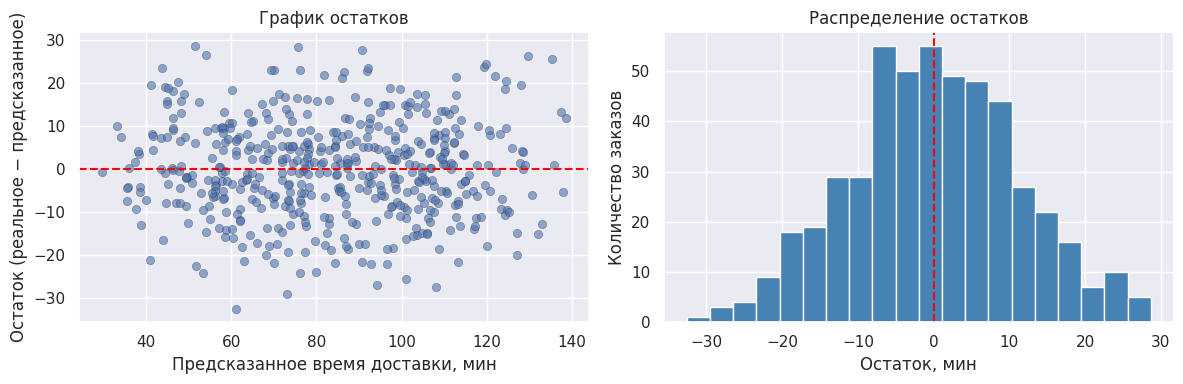

In [ ]:
# Визуализация остатков (residuals) — разницы между реальным и предсказанным временем
residuals = y_reg - y_reg_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_reg_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Предсказанное время доставки, мин')
axes[0].set_ylabel('Остаток (реальное − предсказанное)')
axes[0].set_title('График остатков')

axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остаток, мин')
axes[1].set_ylabel('Количество заказов')
axes[1].set_title('Распределение остатков')
plt.tight_layout()
plt.show()

## МЕТРИКИ БИНАРНОЙ КЛАССИФИКАЦИИ — отток клиентов

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_te, y_clf_pred)
print("Confusion Matrix:")
print(f"  TN={cm[0,0]} (остался, предсказан как оставшийся)")
print(f"  FP={cm[0,1]} (остался, но модель предсказала отток — ложная тревога)")
print(f"  FN={cm[1,0]} (ушёл, но модель не заметила — пропуск оттока)")
print(f"  TP={cm[1,1]} (ушёл, модель поймала)")

# Accuracy — доля правильных ответов
acc = accuracy_score(y_te, y_clf_pred)
print(f"\nAccuracy: {acc:.3f} — доля правильных ответов")

# Precision — из всех, кого модель назвала «уходящими», сколько реально ушло?
prec = precision_score(y_te, y_clf_pred)
print(f"Precision: {prec:.3f} — точность предсказания оттока")

# Recall — из всех реально ушедших, сколько модель нашла?
rec = recall_score(y_te, y_clf_pred)
print(f"Recall: {rec:.3f} — полнота обнаружения оттока")

# F1 — гармоническое среднее Precision и Recall
f1 = f1_score(y_te, y_clf_pred)
print(f"F1-score: {f1:.3f} — баланс между точностью и полнотой")

# ROC-AUC — качество модели при любом пороге
auc = roc_auc_score(y_te, y_clf_proba)
print(f"ROC-AUC: {auc:.3f} — 1.0 идеал, 0.5 случайно")

# Log Loss — штраф за неуверенность в правильных ответах
ll = log_loss(y_te, y_clf_proba)
print(f"Log Loss: {ll:.4f} — чем ближе к 0, тем лучше")

Confusion Matrix:
  TN=176 (остался, предсказан как оставшийся)
  FP=26 (остался, но модель предсказала отток — ложная тревога)
  FN=45 (ушёл, но модель не заметила — пропуск оттока)
  TP=53 (ушёл, модель поймала)

Accuracy: 0.763 — доля правильных ответов
Precision: 0.671 — точность предсказания оттока
Recall: 0.541 — полнота обнаружения оттока
F1-score: 0.599 — баланс между точностью и полнотой
ROC-AUC: 0.783 — 1.0 идеал, 0.5 случайно
Log Loss: 0.5073 — чем ближе к 0, тем лучше


## МЕТРИКИ МНОГОКЛАССОВОЙ КЛАССИФИКАЦИИ

Для демонстрации возьмём тот же отток, но добавим третий класс: «спящий» клиент.
Превратим задачу в многоклассовую: 0 — активный, 1 — спящий, 2 — ушедший.

In [ ]:
# Создадим многоклассовую метку
y_multi = np.where(days_since_last > 60, 2, y_clf)  # если не заходил >60 дней → «спящий» (класс 2)
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_clf, y_multi, test_size=0.3, random_state=42)
clf_multi = LogisticRegression(max_iter=500)
clf_multi.fit(X_tr_m, y_tr_m)
y_multi_pred = clf_multi.predict(X_te_m)

# Classification Report — всё сразу
print("Classification Report (многоклассовая):")
print(classification_report(y_te_m, y_multi_pred, target_names=['Активный', 'Спящий', 'Ушедший']))

# Разные способы усреднения f1_score
f1_macro = f1_score(y_te_m, y_multi_pred, average='macro')
f1_weighted = f1_score(y_te_m, y_multi_pred, average='weighted')
f1_micro = f1_score(y_te_m, y_multi_pred, average='micro')
print(f"F1 (macro): {f1_macro:.3f} — каждый класс одинаково важен")
print(f"F1 (weighted): {f1_weighted:.3f} — большие классы вносят больший вклад")
print(f"F1 (micro): {f1_micro:.3f} — глобальный подсчёт TP/FP/FN (равен accuracy)")

Classification Report (многоклассовая):
              precision    recall  f1-score   support

    Активный       0.78      0.92      0.85       194
      Спящий       0.59      0.32      0.42        74
     Ушедший       0.97      0.97      0.97        32

    accuracy                           0.78       300
   macro avg       0.78      0.74      0.74       300
weighted avg       0.75      0.78      0.75       300

F1 (macro): 0.744 — каждый класс одинаково важен
F1 (weighted): 0.753 — большие классы вносят больший вклад
F1 (micro): 0.777 — глобальный подсчёт TP/FP/FN (равен accuracy)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## МЕТРИКИ КЛАСТЕРИЗАЦИИ — сегментация покупателей

In [ ]:
# Silhouette Score — без истинных меток (от -1 до 1, чем выше, тем лучше)
sil = silhouette_score(X_clus, y_clus_pred)
print(f"Silhouette Score: {sil:.3f} — 1.0 идеально, 0 перекрытие, <0 плохо")

# Davies-Bouldin Index — без истинных меток (чем ниже, тем лучше)
db = davies_bouldin_score(X_clus, y_clus_pred)
print(f"Davies-Bouldin Index: {db:.3f} — 0 лучший, чем ниже, тем лучше")

# Adjusted Rand Index — с истинными метками (1.0 идеально, 0 случайно)
ari = adjusted_rand_score(y_clus_true, y_clus_pred)
print(f"Adjusted Rand Index: {ari:.3f} — 1.0 идеальное совпадение")

# Normalized Mutual Information — с истинными метками (1.0 идеально, 0 случайно)
nmi = normalized_mutual_info_score(y_clus_true, y_clus_pred)
print(f"Normalized Mutual Info: {nmi:.3f} — 1.0 идеальное совпадение")

Silhouette Score: 0.660 — 1.0 идеально, 0 перекрытие, <0 плохо
Davies-Bouldin Index: 0.404 — 0 лучший, чем ниже, тем лучше
Adjusted Rand Index: 0.726 — 1.0 идеальное совпадение
Normalized Mutual Info: 0.735 — 1.0 идеальное совпадение


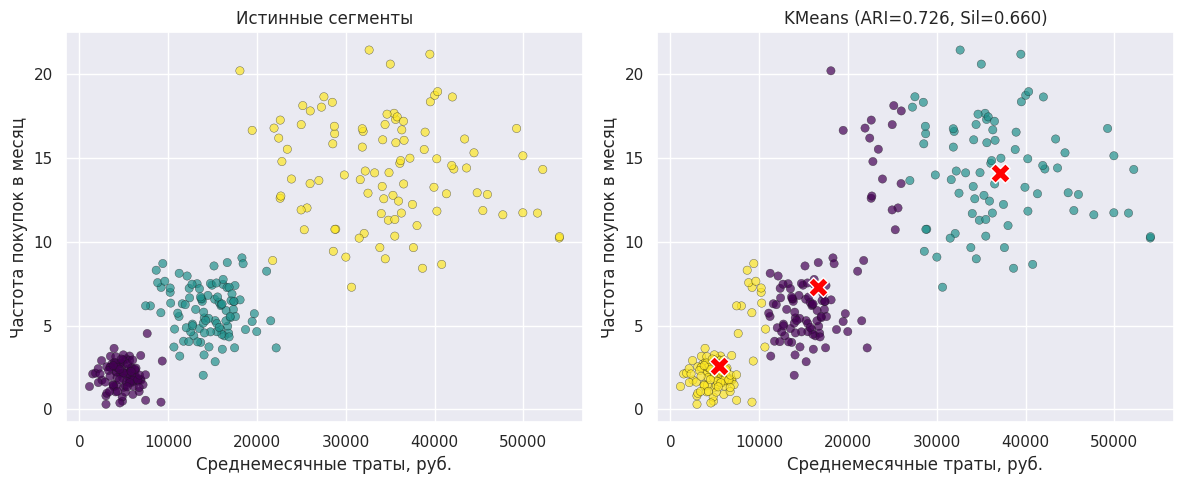

In [ ]:
# Визуализация кластеров
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Истинные метки
axes[0].scatter(X_clus[:, 0], X_clus[:, 2], c=y_clus_true, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[0].set_title('Истинные сегменты')
axes[0].set_xlabel('Среднемесячные траты, руб.'); axes[0].set_ylabel('Частота покупок в месяц')
# Кластеры KMeans
axes[1].scatter(X_clus[:, 0], X_clus[:, 2], c=y_clus_pred, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2], c='red', marker='X', s=200, edgecolors='white')
axes[1].set_title(f'KMeans (ARI={ari:.3f}, Sil={sil:.3f})')
axes[1].set_xlabel('Среднемесячные траты, руб.'); axes[1].set_ylabel('Частота покупок в месяц')
plt.tight_layout()
plt.show()

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Для регрессии попробуй модель `RandomForestRegressor` из sklearn.ensemble. Сравни R² с линейной регрессией.
2. Для классификации оттока построй confusion matrix в виде heatmap.
3. Для кластеризации попробуй n_clusters=2 и n_clusters=5. Как меняется Silhouette Score?
4. Напиши функцию, которая принимает y_true и y_pred и печатает accuracy, precision, recall, f1 и classification report.